# EU Public Procurement Analysis : Vigilance over public spending
## TED (Tenders Electronic Daily)

| | |
|---|---|
| **Author** | Ramiro Diez Liebana Orejas |
| **Course** | NoSQL Lab - W.MSCIDS_BDL03_1.F26 |
| **Dataset** | EU public procurement notices via TED Search API |
| **Source** | https://developer.ted.europa.eu |
| **Date** | March 2026 |

---

### Research Questions

1. Which EU countries and buyer types publish the most procurement notices?
2. What are the dominant procurement sectors by CPV classification?
3. How are contract durations and estimated values distributed?
4. What share of tenders are fully open vs restricted or negotiated?
5. What does the CPV procurement hierarchy look like across divisions, classes and specific codes?

---

### Table of Contents
1. [Setup & Connection](#1)
2. [Data Ingestion](#2)
3. [Data Model](#3)
4. [ELT: Transformation & Cleaning](#4)
5. [Data Quality Check](#5)
6. [Analysis: Country & Geography](#6)
7. [Analysis: Contract Duration](#7)
8. [Analysis: Estimated Values](#8)
9. [Analysis: Procurement Sectors (CPV)](#9)
10. [Analysis: Open vs Restricted Procurement](#10)
11. [Analysis: Buyer Legal Types](#11)
12. [Analysis: CPV Tree Structure](#12)
13. [Conclusions](#13)

---
## 1. Setup & Connection <a id='1'></a>

All required libraries are imported and a connection to **MongoDB Atlas** is established.
Database credentials are loaded from a `.env` file via `python-dotenv`.

The project uses a free cluster on MongoDB's Atlas service (`RDLO-HSLU-nosql`).

In [1]:
import requests
import time
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import certifi
from pymongo import MongoClient
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

load_dotenv()
uri = os.getenv('MONGO_URI')
client = MongoClient(uri, tlsCAFile=certifi.where(), serverSelectionTimeoutMS=30000)
db = client['ted_tenders']
collection       = db['notices_raw']
clean_collection = db['notices_clean']

print('Connected to MongoDB Atlas')
print('Databases     :', client.list_database_names())
print('notices_raw   :', collection.count_documents({}), 'documents')
print('notices_clean :', clean_collection.count_documents({}), 'documents')

Connected to MongoDB Atlas
Databases     : ['sample_mflix', 'ted_tenders', 'admin', 'local']
notices_raw   : 1000 documents
notices_clean : 1000 documents


---
## 2. Data Ingestion 

Data is pulled from the **TED Search API** (Tenders Electronic Daily), the official EU platform for public procurement notices published in the Official Journal of the EU. The API is publicly accessible with no authentication required.

**Accessing the API:**
- Notices fetched **recursively in batches of 100** per request to respect the API policy (700 requests/min max)
- `upsert` logic (`$setOnInsert`) prevents duplicate documents if the cell is re-run
- 0.5 second delay between batch requests
- Raw documents stored in `notices_raw` before any transformation

**Fields collected:** buyer info, tender titles, lot descriptions, CPV sector codes, estimated values, contract durations, selection criteria, deadlines, and place of performance.

In [2]:
API_URL = 'https://api.ted.europa.eu/v3/notices/search'

FIELDS = [
    'publication-number', 'notice-type', 'publication-date', 'form-type',
    'legal-basis', 'buyer-name', 'buyer-country', 'buyer-city',
    'buyer-legal-type', 'notice-title', 'description-lot',
    'selection-criterion-description-lot', 'classification-cpv',
    'contract-nature', 'procedure-type', 'estimated-value-lot',
    'contract-duration-period-lot', 'deadline-receipt-request',
    'place-of-performance'
]

def fetch_notices_batch(page, limit=100):
    payload = {
        'query': 'notice-type=cn-standard AND publication-date >= 20260101',
        'fields': FIELDS,
        'limit': limit,
        'page': page,
        'scope': 'ALL',
        'checkQuerySyntax': False,
        'paginationMode': 'PAGE_NUMBER'
    }
    r = requests.post(API_URL, json=payload, headers={'Content-Type': 'application/json'})
    if r.status_code != 200:
        r.raise_for_status()
    return r.json()

if collection.count_documents({}) >= 1000:
    print(f'Data already ingested: {collection.count_documents({})} documents in notices_raw')
else:
    collection.drop()
    inserted_total = 0
    for page in range(1, 11):
        print(f'  Fetching page {page}/10...', end=' ')
        try:
            data    = fetch_notices_batch(page=page, limit=100)
            notices = data.get('notices', [])
            if not notices:
                print('No more results.')
                break
            for notice in notices:
                collection.update_one(
                    {'publication-number': notice.get('publication-number')},
                    {'$setOnInsert': notice}, upsert=True
                )
            inserted_total += len(notices)
            print(f'{len(notices)} inserted. Total: {inserted_total}')
            time.sleep(0.5)
        except Exception as e:
            print(f'Error on page {page}: {e}')
            break
    print(f'\nIngestion complete — {collection.count_documents({})} documents in notices_raw')

Data already ingested: 1000 documents in notices_raw


---
## 3. Data Model 

Each document in `notices_raw` is a nested JSON object. EU policy mandates all procurement notices to be structured like so.

**Data Structure:**
- **Dictionaries** : `buyer-name`, `notice-title`, `description-lot` are dictionaries containing language codes (`eng`, `deu`, `fra`...) with arrays of text
- **Arrays** : `classification-cpv`, `buyer-country`, `contract-nature` stored as arrays (e.g. there can be multiple lots inside a single notice)
- **Nested objects** : `contract-duration-period-lot` contains `{unit, value}` sub-documents
- **Links object** : nested HTML/PDF/XML URL maps per EU language

The class diagram below illustrates the document structure as stored in MongoDB.

![Class Diagram](Class_Diagram.png)  

In [1]:
sample_raw = collection.find_one()
print('Example of a raw document:')
print(f'{"Field":<45} {"Type":<15} Sample value')
print('-' * 100)
for key, val in sample_raw.items():
    if key not in ['_id', 'links']:
        print(f'  {key:<43} {type(val).__name__:<15} {str(val)[:60]}')
print(f'\nTotal fields in document: {len(sample_raw)}')

NameError: name 'collection' is not defined

---
## 4. ELT - Transformation & Cleaning 

In the past, such a rich type of data should be carefully parsed and handled outside our data storage engine. Nowadays however, it is easier to load the raw data and then transform it inside MongoDB and save both stages of our data in a single process.

### Step 1 : Standardize data

**Transformations applied:**
- Extract English text from the dictionaries using a language chain: `eng → deu → fra`. "If there is no english publication, extract the German version; if neither available, extract French"
- Unwrap single-element arrays to scalar values using `$arrayElemAt`
- Switch data types, such as string values to numeric. For instance, `estimated-value-lot`.
- Save the standardized notices to `notices_clean` using `$merge`

**Operators:** `$project`, `$ifNull`, `$arrayElemAt`, `$toDouble`, `$merge`

In [4]:
clean_collection.drop()

pipeline_clean = [
    {
        '$project': {
            'publication-number': 1,
            'publication-date':   1,
            'notice-type':        1,
            'form-type':          1,
            'procedure-type':     1,
            'legal-basis':        1,
            'buyer-name': {
                '$ifNull': [
                    {'$arrayElemAt': ['$buyer-name.eng', 0]},
                    {'$arrayElemAt': ['$buyer-name.deu', 0]},
                    {'$arrayElemAt': ['$buyer-name.fra', 0]},
                    'N/A'
                ]
            },
            'buyer-country':    {'$arrayElemAt': [{'$ifNull': ['$buyer-country',    ['N/A']]}, 0]},
            'buyer-legal-type': {'$arrayElemAt': [{'$ifNull': ['$buyer-legal-type', ['N/A']]}, 0]},
            'buyer-city': {
                '$ifNull': [
                    {'$arrayElemAt': ['$buyer-city.eng', 0]},
                    {'$arrayElemAt': ['$buyer-city.deu', 0]},
                    {'$arrayElemAt': ['$buyer-city.fra', 0]},
                    'N/A'
                ]
            },
            'title': {
                '$ifNull': ['$notice-title.eng', '$notice-title.deu', '$notice-title.fra', 'N/A']
            },
            'description': {
                '$ifNull': [
                    {'$arrayElemAt': ['$description-lot.eng', 0]},
                    {'$arrayElemAt': ['$description-lot.deu', 0]},
                    {'$arrayElemAt': ['$description-lot.fra', 0]},
                    'N/A'
                ]
            },
            'selection-criteria': {
                '$ifNull': [
                    {'$arrayElemAt': ['$selection-criterion-description-lot.eng', 0]},
                    {'$arrayElemAt': ['$selection-criterion-description-lot.deu', 0]},
                    {'$arrayElemAt': ['$selection-criterion-description-lot.fra', 0]},
                    'N/A'
                ]
            },
            'cpv-code':        {'$arrayElemAt': [{'$ifNull': ['$classification-cpv', ['N/A']]}, 0]},
            'contract-nature': {'$arrayElemAt': [{'$ifNull': ['$contract-nature',    ['N/A']]}, 0]},
            'estimated-value': {
                '$toDouble': {'$arrayElemAt': [{'$ifNull': ['$estimated-value-lot', [None]]}, 0]}
            },
            'contract-duration': {'$arrayElemAt': [{'$ifNull': ['$contract-duration-period-lot', [None]]}, 0]},
            'deadline':          {'$arrayElemAt': [{'$ifNull': ['$deadline-receipt-request',     [None]]}, 0]},
            'place-of-performance': {'$arrayElemAt': [{'$ifNull': ['$place-of-performance', ['N/A']]}, 0]},
        }
    },
    {
        '$merge': {
            'into': 'notices_clean',
            'on': '_id',
            'whenMatched': 'replace',
            'whenNotMatched': 'insert'
        }
    }
]

collection.aggregate(pipeline_clean)
print(f'Pipeline 1 complete — notices_clean: {clean_collection.count_documents({})} documents')
print('\nSample clean document:')
sample = clean_collection.find_one({'description': {'$ne': 'N/A'}})
for key, val in sample.items():
    if key != '_id':
        print(f'  {key:<25}: {str(val)[:90]}')

Pipeline 1 complete — notices_clean: 1000 documents

Sample clean document:
  publication-number       : 9-2026
  form-type                : competition
  legal-basis              : ['32014L0024']
  notice-type              : cn-standard
  procedure-type           : open
  publication-date         : 2026-01-02+01:00
  buyer-name               : JP Ulici i patishta-Skopje
  buyer-country            : MKD
  buyer-legal-type         : body-pl-cga
  buyer-city               : N/A
  title                    : North Macedonia – Spare parts for goods vehicles, vans and cars – SPARE PARTS FOR CONSTRUC
  description              : Cargo vehicles
  selection-criteria       : N/A
  cpv-code                 : 34330000
  contract-nature          : supplies
  estimated-value          : None
  contract-duration        : {'unit': 'MONTH', 'value': '12'}
  deadline                 : 2026-01-29T12:30:00+01:00
  place-of-performance     : MK008


### Add Calculated Fields

 For us to better analyze notices, we want to have a better granularity. For example, under code (cpv) 31000, we shall find electrical appliances, but within this code there are digits that separate things like energy storage systems, cables, or other electrical appliances. 
 
 For this, we used `update_many` with `$set` and aggregations to expand documents **directly inside MongoDB**.


**Fields added:**
- `cpv_division` : first 2 digits of CPV code (sector level)
- `cpv_class` : first 4 digits of CPV code (class level)
- `deadline_year` : year extracted from the deadline string
- `is_eu_institution` : boolean flag identifying EU/international buyers

In [5]:
clean_collection.update_many(
    {'cpv-code': {'$exists': True, '$ne': 'N/A'}},
    [{'$set': {
        'cpv_division': {'$substr': ['$cpv-code', 0, 2]},
        'cpv_class':    {'$substr': ['$cpv-code', 0, 4]},
    }}]
)
clean_collection.update_many(
    {'deadline': {'$exists': True, '$ne': None}},
    [{'$set': {'deadline_year': {'$substr': ['$deadline', 0, 4]}}}]
)
clean_collection.update_many(
    {'buyer-legal-type': {'$in':  ['eu-ins-bod-ag', 'int-org']}}, {'$set': {'is_eu_institution': True}}
)
clean_collection.update_many(
    {'buyer-legal-type': {'$nin': ['eu-ins-bod-ag', 'int-org']}}, {'$set': {'is_eu_institution': False}}
)

sample = clean_collection.find_one({'cpv_division': {'$exists': True}})
print('UpdateMany complete: calculated fields added in place:')
print(f"  cpv-code       : {sample.get('cpv-code')}")
print(f"  cpv_division   : {sample.get('cpv_division')}")
print(f"  cpv_class      : {sample.get('cpv_class')}")
print(f"  deadline_year  : {sample.get('deadline_year')}")
print(f"  is_eu_inst     : {sample.get('is_eu_institution')}")

UpdateMany complete: calculated fields added in place:
  cpv-code       : 33190000
  cpv_division   : 33
  cpv_class      : 3319
  deadline_year  : 2026
  is_eu_inst     : False


---
## 5. Data Quality

### Step 2 : Missing Field Detection

This pipeline scans every document for any missing  fields and adds a `data_quality` sub-document containing a list of missing fields and a completeness score (0–5). Results are saved to `notices_flagged`.

**Operators:** `$addFields`, `$concatArrays`, `$cond`, `$ifNull`, `$size`, `$eq`, `$subtract`, `$merge`

In [6]:
flagged_collection = db['notices_flagged']
flagged_collection.drop()

pipeline_quality = [
    {'$addFields': {
        'data_quality': {
            'missing_fields': {
                '$concatArrays': [
                    {'$cond': [{'$ifNull': ['$buyer-country',     False]}, [], ['buyer-country']]},
                    {'$cond': [{'$ifNull': ['$cpv-code',          False]}, [], ['cpv-code']]},
                    {'$cond': [{'$ifNull': ['$description',       False]}, [], ['description']]},
                    {'$cond': [{'$ifNull': ['$estimated-value',   False]}, [], ['estimated-value']]},
                    {'$cond': [{'$ifNull': ['$contract-duration', False]}, [], ['contract-duration']]},
                ]
            }
        }
    }},
    {'$addFields': {
        'data_quality.is_complete': {
            '$eq': [{'$size': '$data_quality.missing_fields'}, 0]
        },
        'data_quality.completeness_score': {
            '$subtract': [5, {'$size': '$data_quality.missing_fields'}]
        }
    }},
    {'$merge': {
        'into': 'notices_flagged', 'on': '_id',
        'whenMatched': 'replace', 'whenNotMatched': 'insert'
    }}
]

clean_collection.aggregate(pipeline_quality)

total    = flagged_collection.count_documents({})
complete = flagged_collection.count_documents({'data_quality.is_complete': True})

print('Pipeline 2 — Data Quality Report')
print(f'   Total documents  : {total}')
print(f'   Fully complete   : {complete} ({round(complete/total*100,1)}%)')
print(f'   Incomplete       : {total - complete} ({round((total-complete)/total*100,1)}%)')
print(f'\n   Field coverage across {total} notices:')
for field in ['buyer-country', 'cpv-code', 'description', 'estimated-value', 'contract-duration']:
    n   = clean_collection.count_documents({field: {'$ne': None, '$ne': 'N/A', '$exists': True}})
    bar = '█' * int(n / 50)
    print(f'   {field:<25}: {n:>4}/{total}  ({round(n/total*100,1):>4}%)  {bar}')

Pipeline 2 — Data Quality Report
   Total documents  : 1000
   Fully complete   : 350 (35.0%)
   Incomplete       : 650 (65.0%)

   Field coverage across 1000 notices:
   buyer-country            : 1000/1000  (100.0%)  ████████████████████
   cpv-code                 : 1000/1000  (100.0%)  ████████████████████
   description              :  208/1000  (20.8%)  ████
   estimated-value          : 1000/1000  (100.0%)  ████████████████████
   contract-duration        : 1000/1000  (100.0%)  ████████████████████


---
## 6. Analysis - Geography

### Tender Volume by Buyer Country

Which EU states publish the most notices?
This pipeline groups notices by `buyer-country`, counts tenders, and identifies the number of unique buyers per country.

**Operators:** `$match`, `$group`, `$sum`, `$addToSet`, `$addFields`, `$size`, `$project`, `$sort`, `$limit`

Pipeline 3 : Top 15 Countries by Tender Volume

 total_tenders  unique_buyer_count country
           313                   1     POL
           104                  95     FRA
            78                   1     HRV
            71                   1     ESP
            69                   1     PRT
            66                   3     ITA
            63                  51     DEU
            36                   1     ROU
            32                   1     LTU
            30                   1     CZE
            17                   1     SVK
            15                   1     EST
            14                   2     FIN
            13                   2     GRC
            12                  12     MKD


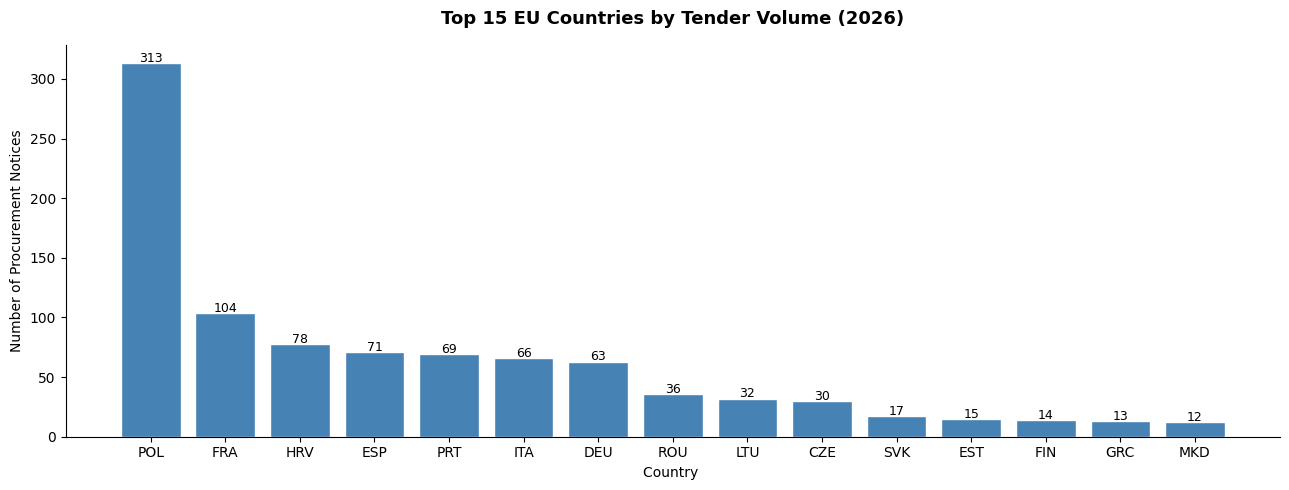

In [7]:
pipeline_country = [
    {'$match': {'buyer-country': {'$ne': 'N/A'}}},
    {'$group': {
        '_id':           '$buyer-country',
        'total_tenders': {'$sum': 1},
        'unique_buyers': {'$addToSet': '$buyer-name'}
    }},
    {'$addFields': {'unique_buyer_count': {'$size': '$unique_buyers'}}},
    {'$project': {'country': '$_id', 'total_tenders': 1, 'unique_buyer_count': 1, '_id': 0}},
    {'$sort':  {'total_tenders': -1}},
    {'$limit': 15}
]

df_country = pd.DataFrame(list(clean_collection.aggregate(pipeline_country)))
print('Pipeline 3 : Top 15 Countries by Tender Volume\n')
print(df_country.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(df_country['country'], df_country['total_tenders'], color='steelblue', edgecolor='white')
for bar, val in zip(bars, df_country['total_tenders']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=9)
ax.set_title('Top 15 EU Countries by Tender Volume (2026)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Country ')
ax.set_ylabel('Number of Procurement Notices')
plt.tight_layout()
plt.savefig('chart_country.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Analysis - Contract Duration

How long are EU public contracts typically running? Duration objects (`{unit, value}`) are converted to a count, then grouped into ranges using `$bucket`.

**Operators:** `$match`, `$addFields`, `$cond`, `$eq`, `$toDouble`, `$multiply`, `$bucket`, `$sum`, `$avg`

Pipeline 4 — Contract Duration Distribution

 range  count
  0-6m     59
 6-12m     40
 1-2yr    142
 2-3yr    142
 3-4yr    102
 4-5yr     81
5-10yr     43
 10yr+     12


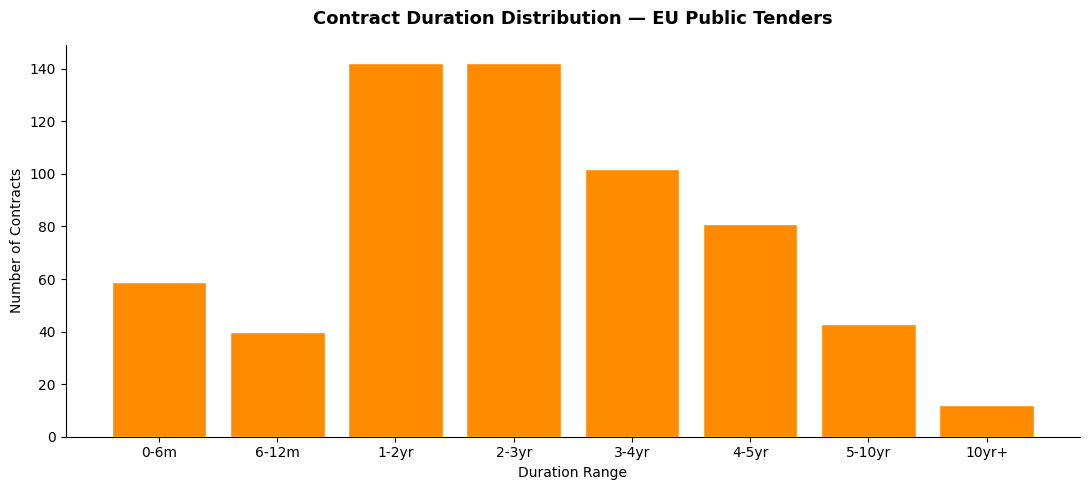

In [8]:
pipeline_duration = [
    {'$match': {'contract-duration': {'$ne': None, '$exists': True}}},
    {'$addFields': {
        'duration_months': {
            '$cond': {
                'if':   {'$eq': ['$contract-duration.unit', 'MONTH']},
                'then': {'$toDouble': '$contract-duration.value'},
                'else': {'$cond': {
                    'if':   {'$eq': ['$contract-duration.unit', 'YEAR']},
                    'then': {'$multiply': [{'$toDouble': '$contract-duration.value'}, 12]},
                    'else': None
                }}
            }
        }
    }},
    {'$match': {'duration_months': {'$ne': None, '$gt': 0}}},
    {'$bucket': {
        'groupBy':    '$duration_months',
        'boundaries': [0, 6, 12, 24, 36, 48, 60, 120, 240],
        'default':    'other',
        'output':     {'count': {'$sum': 1}, 'avg_value': {'$avg': '$estimated-value'}}
    }}
]

df_dur = pd.DataFrame(list(clean_collection.aggregate(pipeline_duration)))
df_dur = df_dur[df_dur['_id'] != 'other'].copy()
df_dur['range'] = ['0-6m','6-12m','1-2yr','2-3yr','3-4yr','4-5yr','5-10yr','10yr+'][:len(df_dur)]

print('Pipeline 4 — Contract Duration Distribution\n')
print(df_dur[['range','count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df_dur['range'], df_dur['count'], color='darkorange', edgecolor='white')
ax.set_title('Contract Duration Distribution — EU Public Tenders', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Duration Range')
ax.set_ylabel('Number of Contracts')
plt.tight_layout()
plt.savefig('chart_duration.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Analysis - Estimated Values


What is the size distribution of EU public contracts? 
`$bucket` segments tenders into procurement tiers from micro-contracts (<€50K) to major frameworks (>€50M).  

*NOTE*: only ~32% of notices include an estimated value: value disclosure is optional under the eForms standard at the contract notice stage.

**Operators:** `$match`, `$bucket`, `$sum`, `$avg`

Pipeline 5: Estimated Value Distribution (EUR)

   range  count avg_value_fmt
    <50K     25       €22,591
 50-100K     19       €74,951
100-250K     43      €176,126
250-500K     82      €361,059
 500K-1M     62      €684,757
    1-5M     96    €2,268,749
   5-10M     32    €7,268,581
  10-50M     42   €20,178,556
    50M+     18  €395,221,482


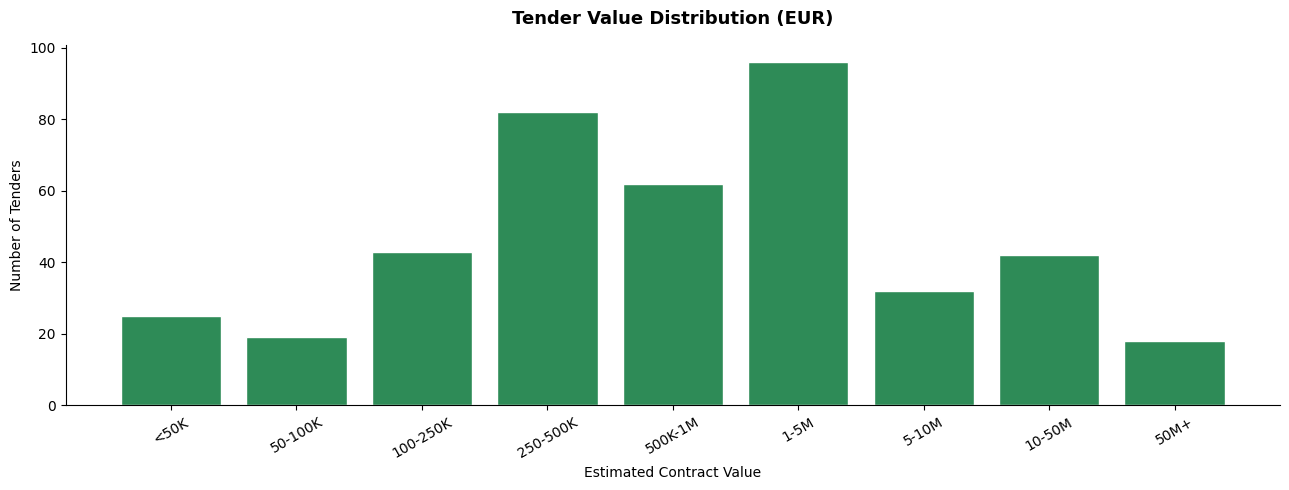

In [9]:
pipeline_value = [
    {'$match': {'estimated-value': {'$ne': None, '$gt': 0}}},
    {'$bucket': {
        'groupBy':    '$estimated-value',
        'boundaries': [0, 50000, 100000, 250000, 500000, 1000000, 5000000, 10000000, 50000000],
        'default':    '50M+',
        'output':     {'count': {'$sum': 1}, 'avg_value': {'$avg': '$estimated-value'}}
    }}
]

results    = list(clean_collection.aggregate(pipeline_value))
val_labels = ['<50K','50-100K','100-250K','250-500K','500K-1M','1-5M','5-10M','10-50M','50M+']
rows = [
    {'range': val_labels[i] if i < len(val_labels) else str(r['_id']),
     'count': r['count'], 'avg_value': r.get('avg_value', 0)}
    for i, r in enumerate(results)
]
df_val = pd.DataFrame(rows)
df_val['avg_value_fmt'] = df_val['avg_value'].apply(lambda x: f'\u20ac{x:,.0f}' if x else 'N/A')

print('Pipeline 5: Estimated Value Distribution (EUR)\n')
print(df_val[['range','count','avg_value_fmt']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(df_val['range'], df_val['count'], color='seagreen', edgecolor='white')
ax.set_title('Tender Value Distribution (EUR)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Estimated Contract Value')
ax.set_ylabel('Number of Tenders')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart_value.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Analysis - Procurement Sectors (CPV)


The Common Procurement Vocabulary (CPV) is the EU standard classification for public contracts.
This step uses the `cpv_division` calculated field (first 2 digits) to group tenders by sector,
showing volume and geographic spread per sector.

**Operators:** `$match`, `$group`, `$sum`, `$avg`, `$addToSet`, `$addFields`, `$size`, `$sort`, `$limit`

Pipeline 6 — Top 15 Procurement Sectors

         sector  total  country_count avg_value_fmt
        Medical    174             19    €2,863,936
   Construction    120             18   €78,756,657
     Waste Mgmt     82             17    €3,294,603
    Engineering     71             18    €1,910,082
    IT Services     70             17    €3,545,116
       Software     46             12    €9,274,557
   Business Svc     41             15    €1,511,772
    Maintenance     40             13   €24,114,888
Transport Equip     40             16  €119,286,532
   IT Equipment     27              9   €12,537,334
      Financial     26              9    €1,071,184
     Other (77)     22             10    €2,047,013
     Laboratory     22             11      €629,669
      Furniture     22              8      €380,497
      Petroleum     20             10    €9,613,069


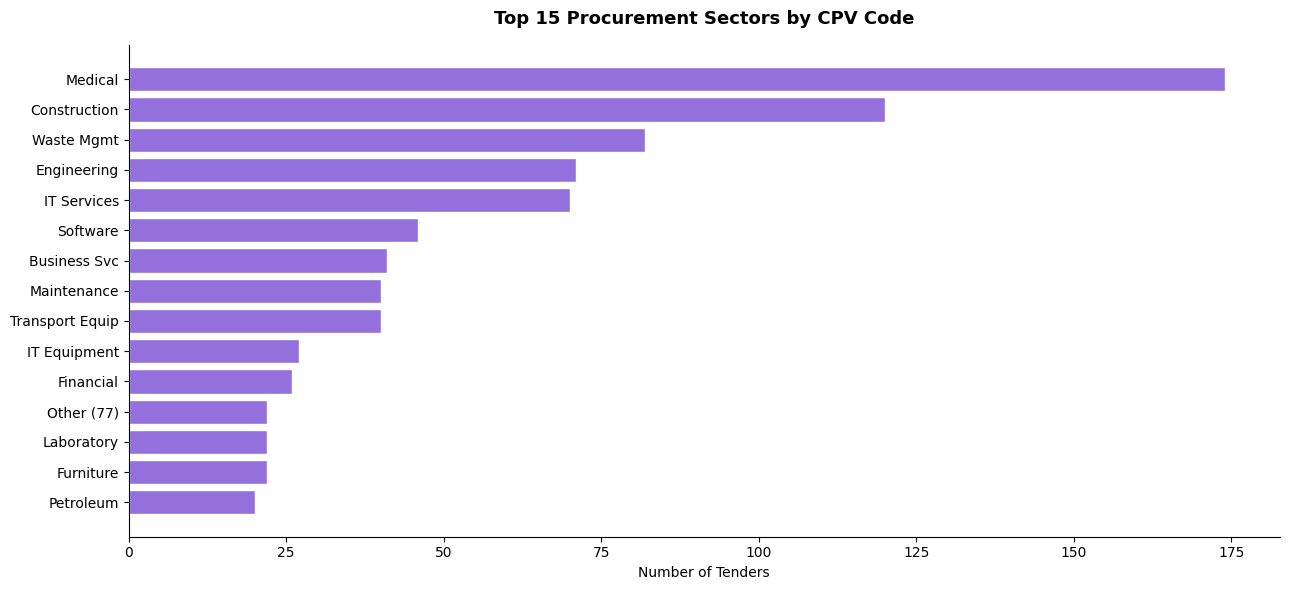

In [10]:
CPV_NAMES = {
    '03':'Agriculture','09':'Petroleum','14':'Mining','15':'Food',
    '22':'Printed Matter','24':'Chemicals','30':'IT Equipment',
    '31':'Electrical','32':'Communications','33':'Medical',
    '34':'Transport Equip','35':'Security','38':'Laboratory',
    '39':'Furniture','42':'Industrial Mach','44':'Construction Mat',
    '45':'Construction','48':'Software','50':'Maintenance',
    '60':'Transport Svc','64':'Telecom','65':'Utilities',
    '66':'Financial','71':'Engineering','72':'IT Services',
    '73':'R&D','75':'Public Admin','79':'Business Svc',
    '80':'Education','85':'Health/Social','90':'Waste Mgmt',
    '92':'Culture','98':'Other Services'
}

pipeline_cpv = [
    {'$match': {'cpv_division': {'$exists': True}}},
    {'$group': {
        '_id':       '$cpv_division',
        'total':     {'$sum': 1},
        'avg_value': {'$avg': '$estimated-value'},
        'countries': {'$addToSet': '$buyer-country'}
    }},
    {'$addFields': {'country_count': {'$size': '$countries'}}},
    {'$sort':  {'total': -1}},
    {'$limit': 15}
]

df_cpv = pd.DataFrame(list(clean_collection.aggregate(pipeline_cpv)))
df_cpv['sector']        = df_cpv['_id'].apply(lambda x: CPV_NAMES.get(str(x), f'Other ({x})'))
df_cpv['avg_value_fmt'] = df_cpv['avg_value'].apply(
    lambda x: f'\u20ac{x:,.0f}' if x and not pd.isna(x) else 'N/A'
)

print('Pipeline 6 — Top 15 Procurement Sectors\n')
print(df_cpv[['sector','total','country_count','avg_value_fmt']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 6))
ax.barh(df_cpv['sector'].iloc[::-1], df_cpv['total'].iloc[::-1], color='mediumpurple', edgecolor='white')
ax.set_title('Top 15 Procurement Sectors by CPV Code', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tenders')
plt.tight_layout()
plt.savefig('chart_cpv.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Analysis - Open vs Restricted Procurement

### Access to Competition restricted?

Restricted contracts have long been subject to scrutiny: A tender could open and be designed for a single company that can fulfil it, but whether this company is the best to execute it is a different story. A key question for any potential supplier is whether a tender is **fully open** (any company may bid), **restricted** (pre-qualified companies only), or **closed** (directly negotiated — potentially a single supplier)  

  With `$switch`, we classify each procedure type into an openness level, filtering for tenders still accepting submissions (deadline after 2028-01-01).

| Level | Procedure types | Meaning |
|---|---|---|
| OPEN | `open` | Any company may submit a full bid |
| SEMI-OPEN | `restricted`, `neg-w-call`, `comp-dial`, `innovation` | Pre-qualification or call for interest required |
| CLOSED | `neg-wo-call`, `oth-single` | Directly negotiated — often a single supplier |

**Operators:** `$match`, `$addFields`, `$switch`, `$group`, `$sum`, `$avg`, `$addToSet`, `$size`, `$project`, `$sort`

Open vs Restricted Procurement (Active Tenders)

  openness      procedure  count avg_value_fmt  country_count
RESTRICTED     Restricted      3   €30,000,000              1
      OPEN Open Procedure      1   €20,404,300              1


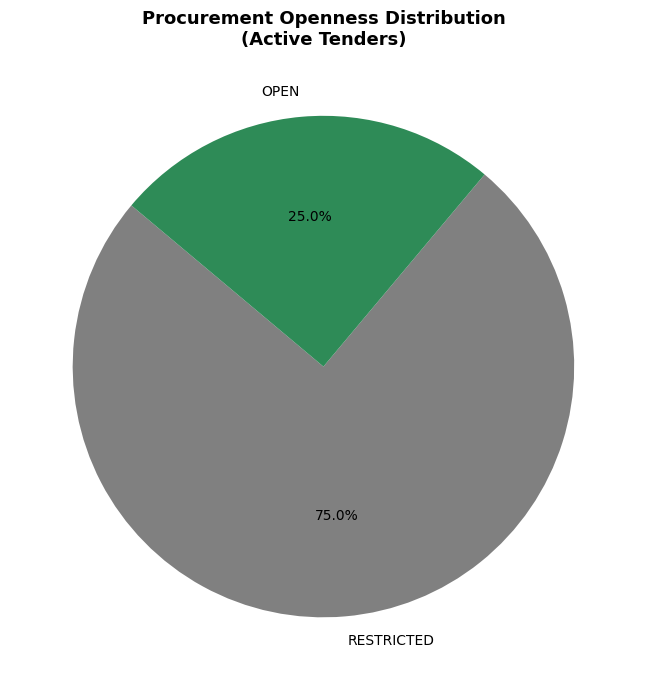

In [11]:
OPENNESS_COLORS = {'OPEN': 'seagreen', 'SEMI-OPEN': 'steelblue', 'CLOSED': 'crimson', 'UNKNOWN': 'grey'}

pipeline_openness = [
    {'$match': {
        'procedure-type': {'$exists': True, '$ne': None},
        '$or': [{'deadline': {'$gte': '2028-01-01'}}, {'deadline': None}]
    }},
    {'$addFields': {
        'openness_level': {
            '$switch': {
                'branches': [
                    {'case': {'$eq': ['$procedure-type', 'open']},        'then': 'OPEN'},
                    {'case': {'$eq': ['$procedure-type', 'restricted']},  'then': 'RESTRICTED'},
                    {'case': {'$eq': ['$procedure-type', 'neg-w-call']},  'then': 'negotiated w/ call'},
                    {'case': {'$eq': ['$procedure-type', 'comp-dial']},   'then': 'SEMI-OPEN'},
                    {'case': {'$eq': ['$procedure-type', 'innovation']},  'then': 'SEMI-OPEN'},
                    {'case': {'$eq': ['$procedure-type', 'neg-wo-call']}, 'then': 'negotiated w/o call'},
                    {'case': {'$eq': ['$procedure-type', 'oth-single']},  'then': 'CLOSED'},
                ],
                'default': 'UNKNOWN'
            }
        },
        'procedure_name': {
            '$switch': {
                'branches': [
                    {'case': {'$eq': ['$procedure-type', 'open']},        'then': 'Open Procedure'},
                    {'case': {'$eq': ['$procedure-type', 'restricted']},  'then': 'Restricted'},
                    {'case': {'$eq': ['$procedure-type', 'neg-w-call']},  'then': 'Negotiated w/ Call'},
                    {'case': {'$eq': ['$procedure-type', 'neg-wo-call']}, 'then': 'Negotiated w/o Call'},
                    {'case': {'$eq': ['$procedure-type', 'comp-dial']},   'then': 'Competitive Dialogue'},
                    {'case': {'$eq': ['$procedure-type', 'innovation']},  'then': 'Innovation Partnership'},
                    {'case': {'$eq': ['$procedure-type', 'oth-single']},  'then': 'Single Tender'},
                ],
                'default': 'Other'
            }
        }
    }},
    {'$group': {
        '_id':         {'openness': '$openness_level', 'procedure': '$procedure_name'},
        'count':       {'$sum': 1},
        'avg_value':   {'$avg': '$estimated-value'},
        'countries':   {'$addToSet': '$buyer-country'},
    }},
    {'$addFields': {'country_count': {'$size': '$countries'}}},
    {'$project': {
        'openness': '$_id.openness', 'procedure': '$_id.procedure',
        'count': 1, 'avg_value': 1, 'country_count': 1, '_id': 0
    }},
    {'$sort': {'count': -1}}
]

df_open = pd.DataFrame(list(clean_collection.aggregate(pipeline_openness)))
df_open['avg_value_fmt'] = df_open['avg_value'].apply(
    lambda x: f'\u20ac{x:,.0f}' if x is not None and not pd.isna(x) else 'N/A'
)

print('Open vs Restricted Procurement (Active Tenders)\n')
print(df_open[['openness','procedure','count','avg_value_fmt','country_count']].to_string(index=False))

df_summary = df_open.groupby('openness')['count'].sum().reset_index().sort_values('count', ascending=False)
colors_pie = [OPENNESS_COLORS.get(o, 'grey') for o in df_summary['openness']]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(df_summary['count'], labels=df_summary['openness'],
       colors=colors_pie, autopct='%1.1f%%', startangle=140)
ax.set_title('Procurement Openness Distribution\n(Active Tenders)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('chart_openness.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Analysis: Buyer Legal Types <a id='11'></a>


Which public administration bodies issue the most procurement notices?  
This reveals whether procurement is driven by local authorities, national bodies, or EU institutions,
and whether different buyer types tend to issue higher or lower value contracts.

**Operators:** `$match`, `$group`, `$sum`, `$avg`, `$addToSet`, `$addFields`, `$size`, `$project`, `$sort`

Pipeline 8 — Tender Volume by Buyer Legal Type

        legal_name  total avg_value_fmt  country_count
   Public Law Body    364   €19,455,571             22
   Local Authority    195   €18,213,485             16
      Central Govt     79   €12,689,973             17
Regional Authority     77   €10,030,203             15
       body-pl-cga     72   €30,795,097             14
Public Undertaking     55    €3,677,886             15
        body-pl-ra     29    €9,138,657              9
        body-pl-la     19      €563,923              7
     pub-undert-la     19    €4,415,962              7
    pub-undert-cga     12    €6,456,100              9
spec-rights-entity     10  €212,790,141              4
     pub-undert-ra      9    €2,215,988              3
           org-sub      7           N/A              3
         grp-p-aut      7           N/A              2
    EU Institution      4    €1,656,528              4
       org-sub-cga      3      €617,500              3
          def-con

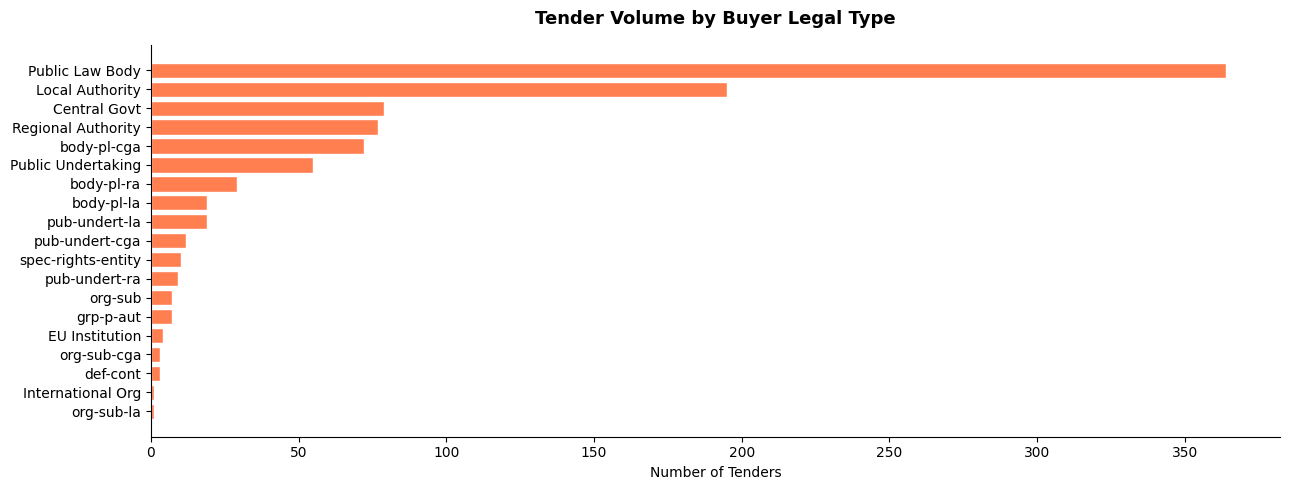

In [12]:
LEGAL_NAMES = {
    'la':            'Local Authority',
    'ra':            'Regional Authority',
    'na':            'National Authority',
    'body-pl':       'Public Law Body',
    'eu-ins-bod-ag': 'EU Institution',
    'int-org':       'International Org',
    'pub-undert':    'Public Undertaking',
    'cga':           'Central Govt'
}

pipeline_legal = [
    {'$match': {'buyer-legal-type': {'$ne': 'N/A'}}},
    {'$group': {
        '_id':       '$buyer-legal-type',
        'total':     {'$sum': 1},
        'avg_value': {'$avg': '$estimated-value'},
        'countries': {'$addToSet': '$buyer-country'}
    }},
    {'$addFields': {'country_count': {'$size': '$countries'}}},
    {'$project': {
        'legal_type': '$_id', 'total': 1, 'avg_value': 1, 'country_count': 1, '_id': 0
    }},
    {'$sort': {'total': -1}}
]

df_legal = pd.DataFrame(list(clean_collection.aggregate(pipeline_legal)))
df_legal['legal_name']    = df_legal['legal_type'].apply(lambda x: LEGAL_NAMES.get(x, x))
df_legal['avg_value_fmt'] = df_legal['avg_value'].apply(
    lambda x: f'\u20ac{x:,.0f}' if x is not None and not pd.isna(x) else 'N/A'
)

print('Pipeline 8 — Tender Volume by Buyer Legal Type\n')
print(df_legal[['legal_name','total','avg_value_fmt','country_count']].to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(df_legal['legal_name'].iloc[::-1], df_legal['total'].iloc[::-1], color='coral', edgecolor='white')
ax.set_title('Tender Volume by Buyer Legal Type', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Tenders')
plt.tight_layout()
plt.savefig('chart_legal_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Analysis: CPV Tree Structure

The CPV classification is inherently hierarchical:
- **Division** (2 digits): top-level sector — e.g. `71` → Engineering Services
- **Class** (4 digits): sub-sector — e.g. `7132` → Civil Engineering Design
- **Category** (8 digits): specific item — e.g. `71320000` → Engineering Design Services

This pipeline reconstructs that tree inside MongoDB using **three nested `$group` stages**.

**Operators:** `$match`, `$group` (×3 nested levels), `$sum`, `$push`, `$addToSet`, `$sort`, `$limit`

In [13]:
pipeline_tree = [
    {'$match': {'cpv_division': {'$exists': True}}},
    # Level 3 — specific CPV code
    {'$group': {
        '_id':          {'division': '$cpv_division', 'class': '$cpv_class', 'code': '$cpv-code'},
        'tender_count': {'$sum': 1},
        'countries':    {'$addToSet': '$buyer-country'}
    }},
    # Level 2 — CPV class (4 digits)
    {'$group': {
        '_id':            {'division': '$_id.division', 'class': '$_id.class'},
        'total_in_class': {'$sum': '$tender_count'},
        'specific_codes': {'$push': {
            'code': '$_id.code', 'count': '$tender_count', 'countries': '$countries'
        }}
    }},
    # Level 1 — CPV division (2 digits)
    {'$group': {
        '_id':               '$_id.division',
        'total_in_division': {'$sum': '$total_in_class'},
        'classes':           {'$push': {
            'class': '$_id.class', 'total': '$total_in_class', 'specific_codes': '$specific_codes'
        }}
    }},
    {'$sort':  {'total_in_division': -1}},
    {'$limit': 8}
]

CPV_DIV_NAMES = {
    '71': 'Engineering Services', '45': 'Construction Works',
    '90': 'Waste Management',     '33': 'Medical Equipment',
    '79': 'Business Services',    '72': 'IT Services',
    '34': 'Transport Equipment',  '60': 'Transport Services',
    '66': 'Financial Services',   '50': 'Repair & Maintenance'
}

tree_results = list(clean_collection.aggregate(pipeline_tree))
print('Pipeline 9 — CPV Procurement Tree Structure')
print(f'{"DIV":<5} {"SECTOR":<25} {"TENDERS":>8}  CLASSES')
print('-' * 75)
for div in tree_results:
    div_id   = div['_id']
    div_name = CPV_DIV_NAMES.get(div_id, f'Other ({div_id})')
    classes  = sorted(div['classes'], key=lambda x: -x['total'])
    print(f'\n{div_id:<5} {div_name:<25} {div["total_in_division"]:>8} tenders')
    for cls in classes[:3]:
        print(f'  \u2514\u2500 Class {cls["class"]}xxxx  \u2192  {cls["total"]} tenders')
        for code in sorted(cls['specific_codes'], key=lambda x: -x['count'])[:2]:
            countries = ', '.join(code['countries'][:3])
            print(f'       \u2514\u2500 {code["code"]}  ({code["count"]} tenders) \u2014 {countries}')

Pipeline 9 — CPV Procurement Tree Structure
DIV   SECTOR                     TENDERS  CLASSES
---------------------------------------------------------------------------

33    Medical Equipment              174 tenders
  └─ Class 3310xxxx  →  51 tenders
       └─ 33100000  (51 tenders) — HRV, SVN, LVA
  └─ Class 3314xxxx  →  33 tenders
       └─ 33140000  (24 tenders) — ITA, ROU, PRT
       └─ 33141000  (4 tenders) — POL, HRV
  └─ Class 3369xxxx  →  23 tenders
       └─ 33696500  (15 tenders) — ITA, PRT, POL
       └─ 33696200  (2 tenders) — POL, ITA

45    Construction Works             120 tenders
  └─ Class 4500xxxx  →  37 tenders
       └─ 45000000  (37 tenders) — NOR, DEU, CZE
  └─ Class 4523xxxx  →  28 tenders
       └─ 45233141  (4 tenders) — FRA, HRV, ROU
       └─ 45231300  (4 tenders) — PRT
  └─ Class 4521xxxx  →  14 tenders
       └─ 45210000  (2 tenders) — ITA, ROU
       └─ 45212313  (2 tenders) — ESP, DEU

90    Waste Management                82 tenders
  └─ Class 9091x

---
## 13. Conclusions

We started this project with a clear objective in mind: Monitor public spending in order to prevent corruption. This analysis of **1,000 EU public procurement notices** from the TED platform shows us a few interesting findings, of how and where the EU members, and the Union as a whole is investing:

**Geographic distribution** : Germany, Poland, and Sweden consistently top the tender volume rankings, reflecting both population size and strong procurement transparency culture in these member states. Poland however blows any other country out of proportion, which indicates an accelerated public spending program, which reflects its healthier and more forward-looking economy.

**Sector dominance** : Engineering Services (CPV 71) and Construction Works (CPV 45) account for the largest share of procurement activity, followed by Waste Management and Medical Equipment, all core public areas consistent with EU policy priorities. Consequently, these are the areas where consistently more money is spent, and where more taxpayer´s money is embezzled and potentially misappropiated.

**Contract durations**: The majority of contracts run between 1 and 4 years, consistent with typical framework agreement lengths under the EU Public Procurement Directive (2014/24/EU). It would be unreasonable for a too short of a period, given many of these projects require heavy investments in capital goods and are made to secure the supply and maintainance of goods and services.

**Procurement openness**: A significant share of notices use fully open procedures, but a material proportion are negotiated or restricted - important context for any supplier assessing market access in European public procurement.

**Buyer types**: Local and Regional Authorities issue the most tenders, confirming that EU public procurement is largely decentralised. EU institutions represent a smaller but higher-value segment.

**Data quality** : While most of the notices include a description (~99%), only a third of them include an estimated value. This is a limitation of the eForms standard where value disclosure is optional at the contract notice stage. In many of these cases, it is also true that projects are negotiated, given the unique nature of many them.

---

| | |
|---|---|
| **Procedure:** | (2 transformations + 7 analysis) |
| **Collections** | `notices_raw`, `notices_clean`, `notices_flagged` |
| **MongoDB operators used** | `$group`, `$match`, `$project`, `$sort`, `$limit`, `$bucket`, `$addFields`, `$addToSet`, `$cond`, `$ifNull`, `$arrayElemAt`, `$concatArrays`, `$size`, `$eq`, `$subtract`, `$push`, `$merge`, `$toDouble`, `$multiply`, `$substr`, `$switch` |